# Simulation for photonic components

## Fiber grating coupler

Let us design a grating coupler for 
- $\lambda_0$ = 1550 nm
- SOI stack with 220 nm thickness
- 8 degree angle fiber

Constraints:
- Min spacing = 200 nm
- Min width = 200 nm


### Basic equations

Let us consider $x$ as the in-plane propagation direction.
The main equation is the Bragg grating condition that states

$$ 
k_{c,x} + G_x = k_{wg}
$$
where
- $k_{c,x} = \beta_c \sin(\theta)$ is the projection of the incident wavevector on the x-axis immersed in the cladding
- $k_{avg} is the average wavevector of the waveguide mode inside the grating
- $G_x = 2\pi/\Lambda$ is the grating vector with a periodicity of $\Lambda$ along the $x$ direction


This gives the starting point for the period
$$
\Lambda = \frac{\lambda}{n_{avg} - n_c \sin(\theta)}
$$

A common approximation for $n_{avg}$ for a grating with teeth is an arithmetic average between the effective index of the two slab modes

$$
n_{eff} = DC n_{wg} + (1 - DC) n_{trench}
$$
with $DC$ being the duty cycle





In [81]:
import numpy as np

# ---- Input parameters ----- #
wl_0 = 1550 # Let us nm
n_c = 1.44  # Refractive index of glass
theta_deg = 8

## Grating parameters
dc = 0.5
n_wg = 2.847  # To be found from simulation
n_trench = 2.538  # To be found from simulation


def grating_period(wl, theta, n_c, n_avg):
    return np.abs(wl / (n_avg - n_c * np.sin(np.deg2rad(theta))))

def average_effective_index(n1, n2, x):
    return x * n1 + (1 - x) * n2

grating_period(wl_0, theta_deg, n_c, average_effective_index(n_wg, n_trench, dc))

np.float64(621.9677231125772)

A better estimation comes by doing a simulation of the waveguide modes, so that is what we are going to do in the next section using Tidy3D



In [1]:
# standard python imports
import matplotlib.pylab as plt
import numpy as np

# tidy3D import
import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

In [82]:
slab_modes = True

if slab_modes:
    Lx, Ly, Lz = 0, 0, 6  # 1D simulation
else:
    Lx, Ly, Lz = 6, 0, 6  # 2D simulation
# size of simulation domain
dl = 0.01

# --- refractive indices at 1550 nm -----------------------------------------
n_si   = 3.476
n_sio2 = 1.444
si   = td.Medium(permittivity=n_si**2,   name="Si")
sio2 = td.Medium(permittivity=n_sio2**2, name="SiO2")

# waveguide information
wg_width = 4
wg_height = 0.15

# central frequency
wl0 = 1.55  # In um
f0 = C_0 / wl0
df = f0 / 20
num_freqs = 3
f0_ind = num_freqs // 2
freqs = np.linspace(f0 - df / 2, f0 + df / 2, num_freqs)

# run_time in ps
run_time = 1e-11

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wl0)

waveguide = td.Structure(  # pyright: ignore[reportCallIssue]
    geometry=td.Box(size=(wg_width, td.inf, wg_height)),  # pyright: ignore[reportCallIssue]
    medium=si,
)



# now just set these in the boundary spec along the appropriate dimensions
bspec_pml_per = td.BoundarySpec(y=td.Boundary.periodic(),   # Propagation direction   # pyright: ignore[reportCallIssue]
                                x=td.Boundary.periodic() if slab_modes else td.Boundary.pml(), # in plane direction
                                z=td.Boundary.pml()) # Stack direction

sim = td.Simulation(  # pyright: ignore[reportCallIssue]
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide],
    medium=sio2,
    run_time=run_time,
    boundary_spec=bspec_pml_per,
)


plane = td.Box(center=(0, 0, 0), size=(5, 0, 4))
mode_spec = td.ModeSpec(
    num_modes=4,
)

mode_simulation = td.ModeSimulation.from_simulation(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)

# sim.plot(y=0)
sim_data = mode_simulation.run_local()
mode_data = sim_data.modes


/workspace/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:42: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Ny, Ny)))
/workspace/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:55: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dyb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Ny, Ny)))


14:47:41 UTC WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 2, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 2, mode index 3 does not    
             decay at the plane boundaries.                                     

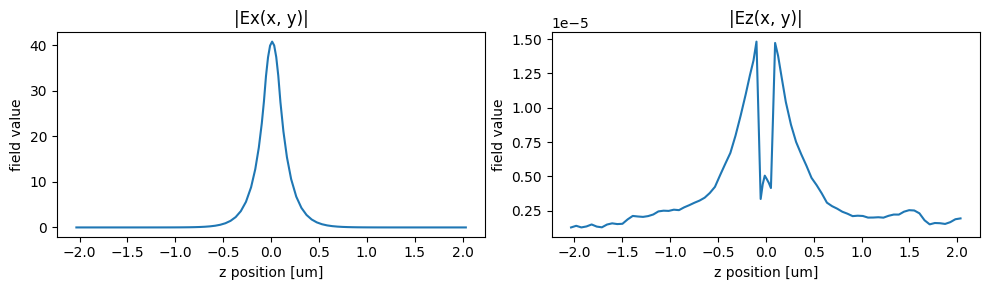

In [83]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="z", ax=ax1)
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="z", ax=ax2)

ax1.set_title("|Ex(x, y)|")
# ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
# ax2.set_aspect("equal")
plt.show()

In [84]:
mode_data.to_dataframe()

wavelength     n eff  k eff  TE (Ex) fraction  \
f            mode_index                                                  
1.885791e+14 0             1.589744  2.523473    0.0      1.000000e+00   
             1             1.589744  1.603912    0.0      1.760971e-12   
             2             1.589744  1.436002    0.0      4.516383e-10   
             3             1.589744  1.424679    0.0      6.816052e-09   
1.934145e+14 0             1.550000  2.545475    0.0      1.000000e+00   
             1             1.550000  1.617392    0.0      1.141341e-11   
             2             1.550000  1.436474    0.0      2.000523e-11   
             3             1.550000  1.426123    0.0      7.979169e-11   
1.982499e+14 0             1.512195  2.566827    0.0      1.000000e+00   
             1             1.512195  1.631879    0.0      6.434456e-12   
             2             1.512195  1.436931    0.0      2.227665e-10   
             3             1.512195  1.427407    0.0      1.011123e-10   

                         wg TE fraction  wg TM fraction  mode area  
f            mode_index                                             
1.885791e+14 0                 1.000000        0.743072   0.298151  
             1                 0.820842        1.000000   0.808065  
             2                 0.991929        1.000000   3.192056  
             3                 0.959469        1.000000   2.256982  
1.934145e+14 0                 1.000000        0.745585   0.289906  
             1                 0.809167        1.000000   0.763270  
             2                 0.992438        1.000000   3.200735  
             3                 0.963113        1.000000   2.263432  
1.982499e+14 0                 1.000000        0.748160   0.282247  
             1                 0.797151        1.000000   0.722323  
             2                 0.992911        1.000000   3.211291  
             3                 0.966321        1.000000   2.272505

In [85]:
n_wg = 2.850
n_trench = 2.545
grating_period(wl_0, theta_deg, n_c, average_effective_index(n_wg, n_trench, dc))

np.float64(620.7223384045045)

## Simulation of the grating coupler

Once we have a starting point $\Lambda_0$ and $DC_0$, we are going to sweep two parameters:
- period $\Lambda$
- duty cycle $DC$

Let us confirm the result with a 2D simulation

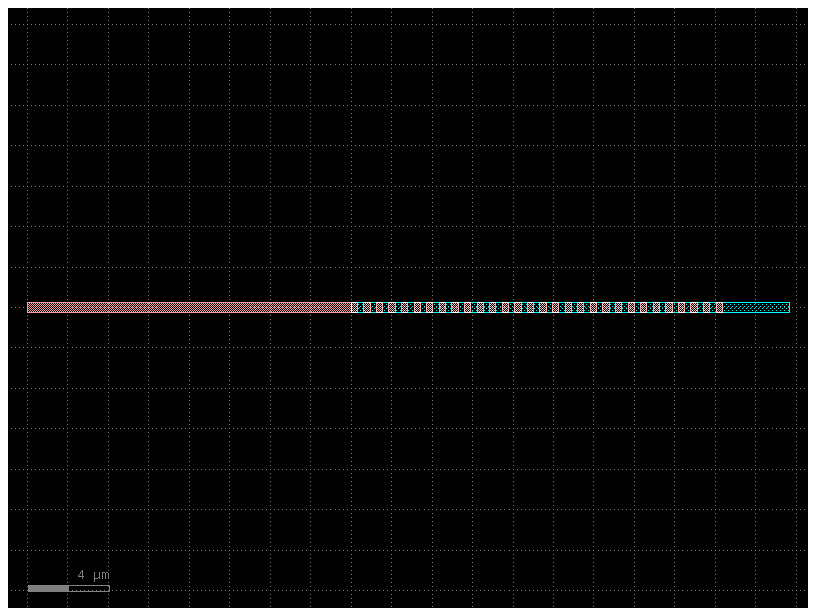

In [112]:
import gdsfactory as gf
gf.clear_cache()


@gf.cell
def simple_grating(period, duty_cycle=0.5, n_periods=30, taper_length = 16, cross_section="strip", layer_slab = "SLAB150",):

    xs = gf.get_cross_section(cross_section)

    wg_width = xs.width
    layer = xs.layer

    c = gf.Component()
    grating_length = (n_periods) * period
    wg = c << gf.components.straight(length=taper_length)

    line_width = duty_cycle * period
    tooth_poly = np.array([
        (0., -wg_width/2),
        (0., wg_width/2),
        (line_width, wg_width/2),
        (line_width, -wg_width/2),
    ])

    for p in range(n_periods):
        v = np.array([taper_length + p * period, 0])
        c.add_polygon(tooth_poly + v, layer=layer)

    # c.add_port(
    #     name="o1",
    #     center=(0, 0),
    #     width=wg_width,
    #     orientation=180,
    #     port_type="optical",
    # )
    c.add_ports([wg.ports["o1"]])

    if layer_slab is not None:
        slab_poly = np.array([
            (0., -wg_width/2),
            (0., wg_width/2),
            (grating_length + 3, wg_width/2),
            (grating_length + 3, -wg_width/2),
        ])
        v = np.array([taper_length, 0])
        c.add_polygon(slab_poly + v, layer=layer_slab)

    c.add_port(
        name="o2",
        center=(0, 0),
        width=wg_width,
        orientation=180,
        layer=layer,
        port_type=f"vertical_te",
    )

    return c

gc = simple_grating(0.622)
gc


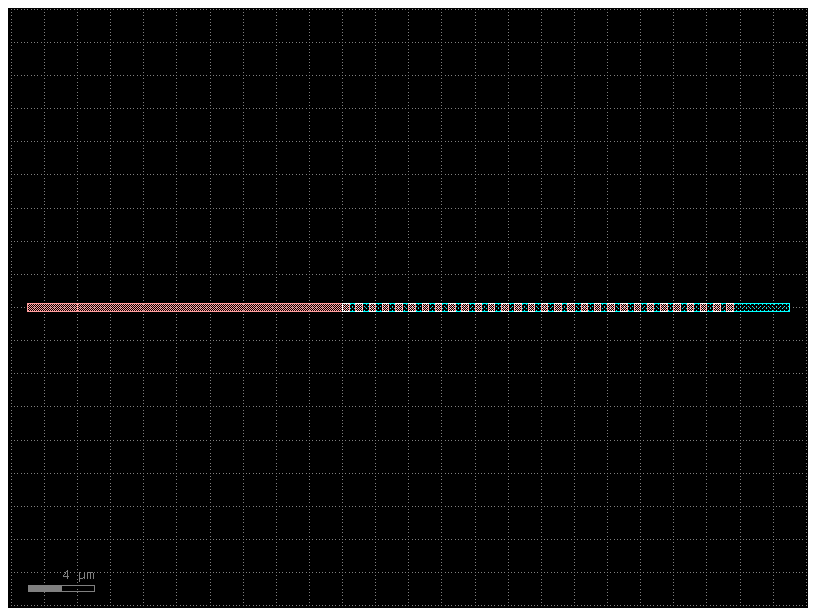

In [126]:
import gdsfactory as gf

# gf.clear_cache()

gf.gpdk.PDK.activate()



# @gf.cell
def create_grating_geometry(**grating_params):
    c = gf.Component()
    # gc = gf.components.grating_coupler_elliptical(grating_line_width=0.570 * 0.5,
    #                                               wavelength=1.55,                                    
    #                                               fiber_angle=8,
    # )
    gc = simple_grating(**grating_params)

    gc_r = c.add_ref(gc)
    s_r = c.add_ref(gf.components.straight(length=3))
    s_r.connect("o1", gc_r.ports["o1"])
    c.add_port("o2", port=s_r.ports["o2"])
    return c

c = create_grating_geometry(period=0.8, duty_cycle=0.5)
c

/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'Aluminum' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('Aluminum', refractive_index=...) to include it.
  material_data = resolve_materials(
/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'TiN' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('TiN', refractive_index=...) to include it.
  material_data = resolve_materials(
/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'ge' has no optical properties (refractive_index) — layer will be omitted from simulation. Use sim.set_material('ge', refractive_index=...) to include it.
  material_data = resolve_materials(
/workspace/.venv/lib/python3.12/site-packages/gsim/meep/simulation.py:713: UserWarning: Material 'passive' has no optic

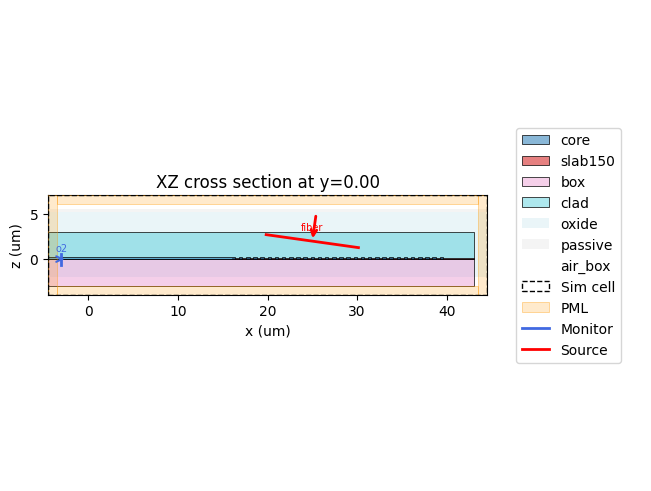

In [127]:
from gsim import meep
from gsim.common.stack import get_stack


def create_simulation(geometry_fn, geometry_params):
    stack = get_stack()  # auto-detects active PDK

    sim = meep.Simulation()

    c = geometry_fn(**geometry_params)

    sim.geometry(component=c, stack=stack)
    sim.materials = {"si": 3.48, "SiO2": 1.44}

    sim.solver(resolution=25, is_3d=False, plane="xz", save_animation=True)
    sim.solver.stop_when_energy_decayed()

    sim.source_fiber(
        x=25.0, z=2,
        angle_deg=-8.0,
        waist=5.2,
        wavelength=1.55,
        wavelength_span=0.06,
        polarization="TE",
    )


    sim.monitors = ["o2"]
    sim.domain(pml=1.0, margin=0.5)
    sim.num_freqs = 21

    # print(sim.validate_config())
    
    return sim

params = dict(period=0.8, duty_cycle=0.5)
sim = create_simulation(create_grating_geometry, params)
sim.plot_2d(slices="y")


In [128]:
import pandas as pd

periods = np.arange(0.57, 0.62, 0.01)
duty_cycles = [0.4, 0.5, 0.6]

rows = []

for p in periods:
    for dc in duty_cycles:
        params = dict(period=p, duty_cycle=dc)
        sim = create_simulation(create_grating_geometry, params)
        result = sim.run()
        rows.append(
            {"period": p, "duty_cycle": dc, "result": result}
        )
# result.plot_interactive()

  meep-c042d166  completed  2m 21s
Extracting results.tar.gz...
Downloaded 325 files to /workspace/notebooks/sim-data-meep-c042d166


In [155]:
def lin2db(x):
    return 20 * np.log10(np.abs(x))

def extract_peak_insertion_loss(result, wavelength=1.55, transform=None, sparam_key="S10"):
    transform = transform or lin2db

    idx = np.where(np.array(result.wavelengths) == wavelength)[0][0]

    v = result.s_params[sparam_key]
    mag = transform(v)
    return mag[idx]

# extract_peak_insertion_loss(rows[0]["result"])

df = pd.DataFrame(rows)
df["IL@1.55um"] = df["result"].apply(extract_peak_insertion_loss)
df


,period,duty_cycle,result,IL@1.55um
0,0.57,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-26.277826
1,0.57,0.5,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-19.864007
2,0.57,0.6,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-16.328056
3,0.58,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-19.744352
4,0.58,0.5,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-11.555001
5,0.58,0.6,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-7.313901
6,0.59,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-8.888294
7,0.59,0.5,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-5.396245
8,0.59,0.6,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-3.418854
9,0.60,0.4,"wavelengths=[1.580604, 1.577489, 1.574387, 1.5...",-4.093316


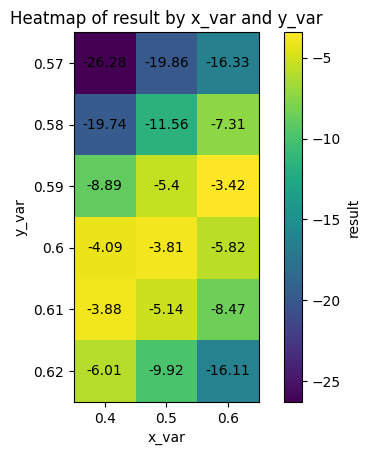

In [156]:
heatmap_data = df.pivot_table(
    index="period",
    columns="duty_cycle",
    values="IL@1.55um",
    # aggfunc="mean"
)

fig, ax = plt.subplots()

# Create heatmap
im = ax.imshow(heatmap_data.values)

# Axis labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Add values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.values[i, j]
        ax.text(j, i, round(value, 2), ha="center", va="center")

# Add colorbar
plt.colorbar(im, ax=ax, label="result")

ax.set_xlabel("x_var")
ax.set_ylabel("y_var")
ax.set_title("Heatmap of result by x_var and y_var")

plt.show()

## Splitter

For a broadband splitter 2x2 we need to use a multimode-interferometer, which they generally have more bandwidth than a directional coupler

In [4]:
import numpy as np
import tidy3d as td
import tidy3d.web as web
from matplotlib import pyplot as plt
from tidy3d.plugins import waveguide

In [5]:
# --- refractive indices at 1550 nm -----------------------------------------
n_si   = 3.476
n_sio2 = 1.444
si   = td.Medium(permittivity=n_si**2,   name="Si")
sio2 = td.Medium(permittivity=n_sio2**2, name="SiO2")


l = 6
h = 0.22
w = 0.45
g = 0.05

geo = td.GeometryGroup(
    geometries=[
        td.Box(size=(w, h, 2 * l), center=(-(w + g) / 2, 0, 0)),
        td.Box(size=(w, h, 2 * l), center=((w + g) / 2, 0, l)),
    ]
)

wvgs = td.Structure(geometry=geo, medium=si)

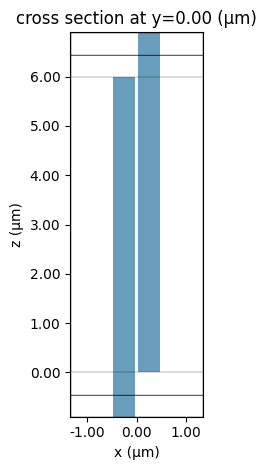

In [7]:
eme_grid_spec = td.EMEExplicitGrid(
    boundaries=[0, l],
    mode_specs=[
        td.EMEModeSpec(num_modes=2),
        td.EMEModeSpec(num_modes=4),
        td.EMEModeSpec(num_modes=2),
    ],
)

eme_field_mon = td.EMEFieldMonitor(name="field", size=(td.inf, 0, td.inf))

lengths = np.linspace(l, 6 * l, 100)

eme_sim = td.EMESimulation(
    center=(0, 0, l / 2),
    size=(6 * w, h + 4 * w, l + 4 * w),
    structures=[wvgs],
    medium=sio2,
    symmetry=(0, 1, 0),
    grid_spec=td.GridSpec.auto(min_steps_per_wvl=10),
    monitors=[eme_field_mon],
    eme_grid_spec=eme_grid_spec,
    freqs=[td.C_0 / 1.55],
    axis=2,
    port_offsets=(w, w),
)

eme_sim_sweep = eme_sim.updated_copy(
    sweep_spec=td.EMELengthSweep(scale_factors=list(lengths / l)), monitors=[]
)

_ = eme_sim.plot(y=0, monitor_alpha=0)
plt.show()

In [8]:
mode_data = [ms.run_local() for ms in eme_sim.mode_simulations]
smatrix = eme_sim.propagate(mode_data)

15:51:06 UTC WARNING: Local EME propagation returns only the device S-matrix.   
             The 1 monitor(s) configured on this simulation                     
             (EMEFieldMonitor(name='field', center=(0.0, 0.0, 0.0), size=(inf,  
             0.0, inf))) will be dropped; run the simulation through the remote 
             backend instead if you need monitor data.                          

15:51:07 UTC WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

15:51:08 UTC WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

15:51:09 UTC WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             ERROR: The feature 'local_eme' is not available with your license. 
             Please contact Tidy3D support, or upgrade your license.            

Tidy3dImportError: The feature 'local_eme' is not available with your license. Please contact Tidy3D support, or upgrade your license.

## Silicon nitride bend

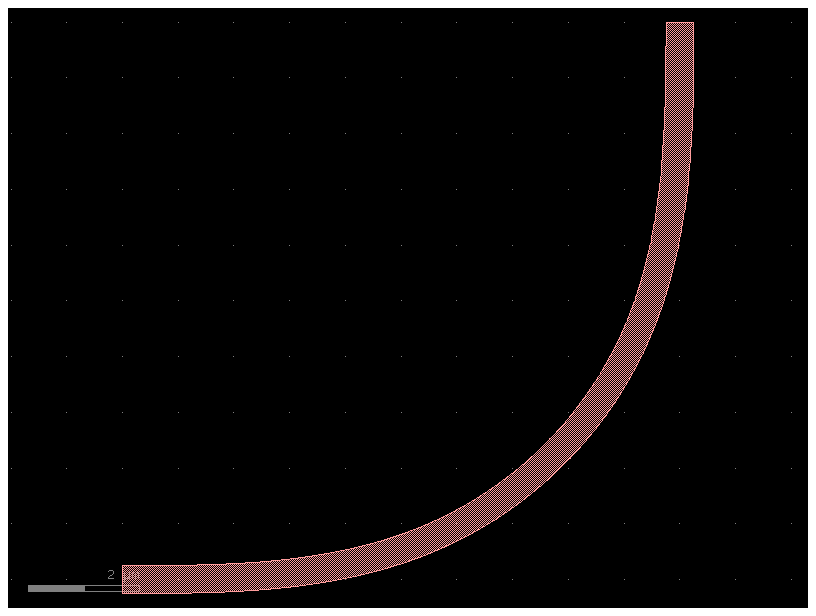

In [1]:
import gdsfactory as gf

gf.gpdk.PDK.activate()

c = gf.components.bend_euler()
c

In [2]:
# standard python imports
import matplotlib.pylab as plt
import numpy as np

# tidy3D import
import tidy3d as td
from tidy3d.plugins import waveguide
from tidy3d.constants import C_0

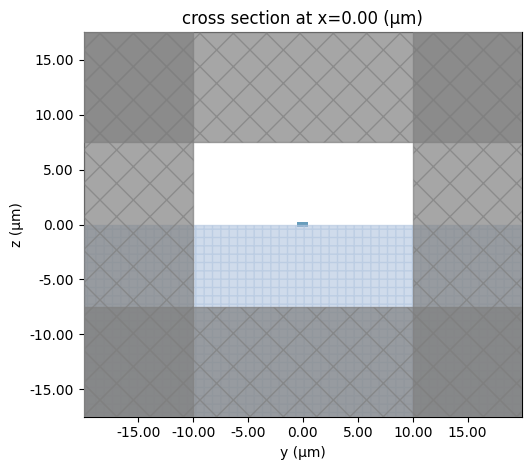

In [3]:
td.config.logging_level = "ERROR"

# function to define the mode solver
def mode_solver_SiN_wvg(
    wg_size=(1., 0.4),
    wavelength=1.55,
    resolution=10,
    npml=12,
    delta_override=None,
    size=(20, 15),
    num_modes=10,
    target_neff=None,
    bend_radius=None,
    bend_axis=1,
    symmetry=(0, 0, 1),
    fields=["Ex", "Ey", "Ez"],
):
    siN = td.Medium(permittivity=1.996**2)
    sio2 = td.Medium(permittivity=1.44**2)

    structures = [td.Structure(geometry=td.Box(size=(100, 1, 0.4)), medium=siN)]

    mode_spec = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        precision="double",
        bend_radius=bend_radius,
        bend_axis=bend_axis,
        num_pml=(npml, npml),
        group_index_step=True,
        # track_freq=
    )

    if delta_override:
        mesh_override = [
            td.MeshOverrideStructure(
                geometry=td.Box(center=(0, 0, 0), size=(0, 2 * 0.6, 2 * 0.22)),
                dl=(delta_override,) * 3,
            )
        ]
    else:
        mesh_override = []

    grid_spec = td.GridSpec.auto(
        min_steps_per_wvl=resolution, 
        wavelength=wavelength, 
        override_structures=mesh_override
    )

    sim = td.Simulation(
        size=(10, size[0], size[1]),
        center=(0, 0, 0),
        grid_spec=grid_spec,
        structures=structures,
        sources=[],
        monitors=[],
        run_time=1e-12,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
        symmetry=symmetry,
        medium=sio2,
    )

    plane = td.Box(center=(0, 0, 0), size=(0, size[0], size[1]))

    mode_solver = td.ModeSimulation.from_simulation(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec,
        freqs=[td.C_0 / wavelength],
        fields=fields,
    )

    return mode_solver

ms = mode_solver_SiN_wvg(10, 12)
ms.plot(x=0)
plt.show()

In [4]:
# function to decide if a mode is a valid solution
def isMode(mode_data, mode_index, radius=1, freq_index=0):
    E = abs(mode_data.Ex**2 + mode_data.Ey**2 + mode_data.Ez**2)[0, :, :, freq_index, mode_index]
    center = (
        E.y.min() + (E.y.max() - E.y.min()) / 2,
        E.z.min() + (E.z.max() - E.z.min()) / 2,
    )

    bmInside = (abs(E.y) < (center[0] + radius)) & (abs(E.z) < (center[1] + radius))

    if E.values[bmInside].sum() > E.values[~bmInside].sum():
        return True
    else:
        return False


# function to find the first valid mode
def findMode(mode_data, radius=1):
    for i in range(mode_data.Ex.shape[-1]):
        if isMode(mode_data, i, radius):
            return i
    return None

In [ ]:
# td.config.logging_level = True

radius = np.arange(15, 75, 10)
data = []

for r in radius:
    mode_solver = mode_solver_SiN_wvg(
        resolution=10,
        npml=12,
        num_modes=5,
        target_neff=1.678,
        bend_radius=r,
        bend_axis=1,
        size=(20, 15),
    )

    sim_data = mode_solver.run_local()
    mode_data = sim_data.modes

    idx = findMode(mode_data, 0.4)

    l = mode_data.to_dataframe().iloc[idx]
    data.append(l)



c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tid

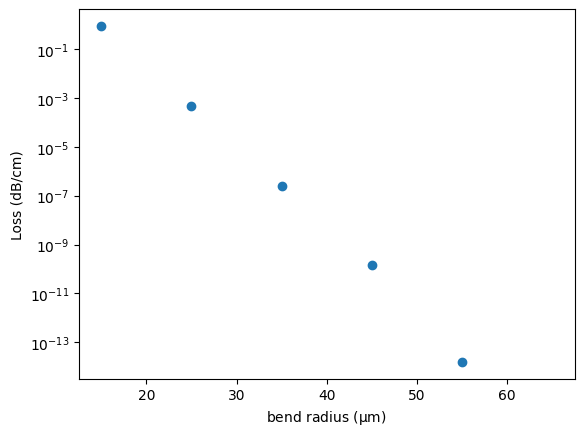

In [8]:
fig, ax = plt.subplots()
ax.plot(radius, loss, "o")
ax.set_yscale("log")
ax.set_xlabel("bend radius ($\\mu$m)")
ax.set_ylabel("Loss (dB/cm)")
plt.show()

<Axes: title={'center': 'cross section at x=0.00 (μm)'}, xlabel='y (μm)', ylabel='z (μm)'>

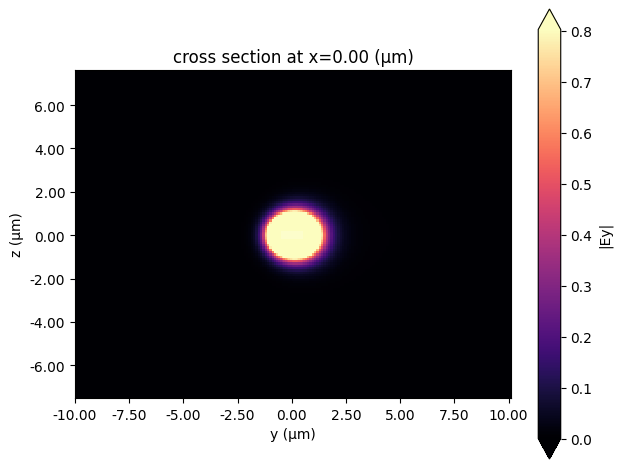

In [139]:
sim_data.plot_field(field_name="Ey", val='abs', mode_index=2)

In [9]:
mode_solver = mode_solver_SiN_wvg(
        resolution=10,
        npml=12,
        num_modes=5,
        target_neff=1.678,
        bend_radius=20,
        bend_axis=1,
        size=(20, 15),
    )

sim_data = mode_solver.run_local()
mode_data = sim_data.modes

idx = findMode(mode_data, 0.4)

l = mode_data.to_dataframe().iloc[idx]

c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\reza49\Documents\Git\photonics\sipho\.venv\Lib\site-packages\tid

In [10]:
l

wavelength                       1.55
n eff                        1.678399
k eff                             0.0
loss (dB/cm)                 0.020209
TE (Ey) fraction                 None
wg TE fraction                   None
wg TM fraction                   None
mode area                        None
group index                  2.061928
dispersion (ps/(nm km))   -486.233027
Name: (193414489032258.06, 2), dtype: object

### Analytical model

In this case, we are trying to use only an analytical approach

151672.46684774282 0.783373959666557


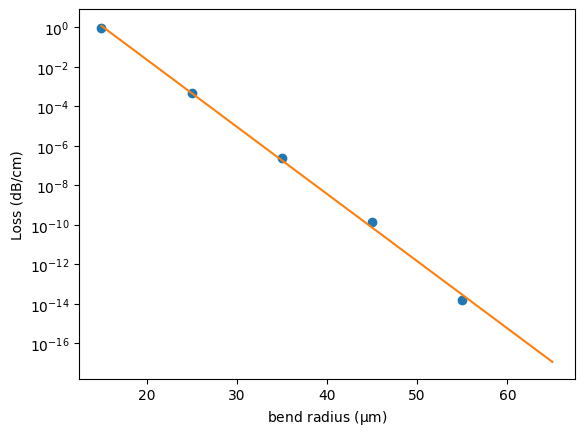

In [16]:
import numpy as np
from scipy.optimize import curve_fit


def loss_exp(R, A, B):
    """
    Simple exponential bend-loss model.

    R: bend radius
    A: loss scale
    B: exponential decay rate
    """
    return A * np.exp(-B * R)


def fit_loss_exp(R, loss):
    R = np.asarray(R, dtype=float)
    loss = np.asarray(loss, dtype=float)

    mask = np.isfinite(R) & np.isfinite(loss) & (loss > 0)
    R_fit = R[mask]
    loss_fit = loss[mask]

    # Fit in log-space for stability
    y = np.log(loss_fit)

    def log_model(R, logA, B):
        return logA - B * R

    popt, pcov = curve_fit(log_model, R_fit, y)
    logA, B = popt

    A = np.exp(logA)

    return {
        "A": A,
        "B": B,
        "cov": pcov,
        "model": lambda R_new: loss_exp(np.asarray(R_new), A, B),
    }


fit = fit_loss_exp(radius, loss)

R_smooth = np.linspace(min(radius), max(radius), 300)
loss_smooth = fit["model"](R_smooth)

print(fit["A"], fit["B"])


fig, ax = plt.subplots()
ax.plot(radius, loss, "o")
ax.plot(R_smooth, loss_smooth)
ax.set_yscale("log")
ax.set_xlabel("bend radius ($\\mu$m)")
ax.set_ylabel("Loss (dB/cm)")
plt.show()

70.686


Text(0, 0.5, 'Curvature')

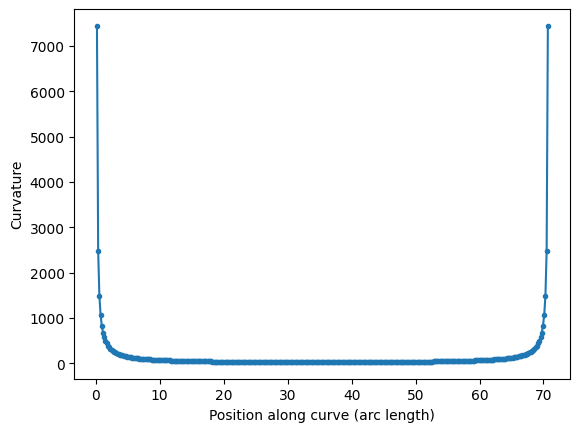

In [ ]:
import gdsfactory as gf

p = gf.path.euler(radius=30, p=0.5)
s, K = p.curvature()

print(p.length())
plt.plot(s, 1/K, ".-")
plt.xlabel("Position along curve (arc length)")
plt.ylabel("Radius of Curvature")

np.float64(7.049814747373324)

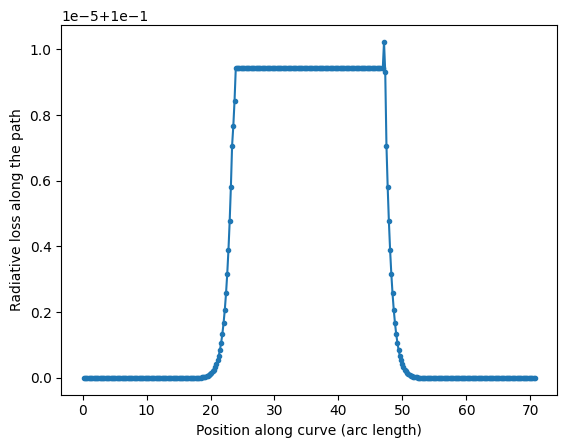

In [29]:
rho = 1 / K
alpha_propagation = 0.1  # dB/cm
alpha_rho = fit["model"](rho)
total_alpha = alpha_propagation + alpha_rho

plt.plot(s, total_alpha, ".-")
plt.xlabel("Position along curve (arc length)")
plt.ylabel("Radiative loss along the path")

total_loss = np.trapezoid(total_alpha, s)
total_loss

In [32]:
import numpy as np
import pandas as pd
import gdsfactory as gf


def compute_euler_loss(
    radius,
    p_value,
    fit,
    *,
    alpha_propagation=0.1 / 1e4, # dB/um
    angle=90,
    use_eff=False,
    npoints=720,
    min_curvature=1e-12,
):
    """
    Compute total loss for one gdsfactory Euler bend.

    Parameters
    ----------
    radius : float
        Euler bend radius passed to gf.path.euler.
    p_value : float
        Euler p parameter passed to gf.path.euler.
    fit : dict
        Fit result containing fit["model"](rho), where rho is bend radius.
        The model should return bend loss per unit length in the same
        units as alpha_propagation.
    alpha_propagation : float
        Propagation loss per unit length.
    angle : float
        Bend angle in degrees.
    use_eff : bool
        Passed to gf.path.euler.
    npoints : int
        Number of points used in the Euler path.
    min_curvature : float
        Curvature below this is treated as straight, with infinite radius.

    Returns
    -------
    dict
        Summary of the bend loss calculation.
    """

    path = gf.path.euler(
        radius=radius,
        p=p_value,
        angle=angle,
        use_eff=use_eff,
        npoints=npoints,
    )

    s, K = path.curvature()
    s = np.asarray(s, dtype=float)
    K = np.asarray(K, dtype=float)

    abs_K = np.abs(K)

    rho = np.full_like(abs_K, np.inf)
    bend_mask = abs_K > min_curvature
    rho[bend_mask] = 1 / abs_K[bend_mask]

    alpha_rho = np.zeros_like(s)
    alpha_rho[bend_mask] = fit["model"](rho[bend_mask])

    total_alpha = alpha_propagation + alpha_rho

    propagation_loss = np.trapezoid(
        np.full_like(s, alpha_propagation),
        s,
    )
    bend_loss = np.trapezoid(alpha_rho, s)
    total_loss = np.trapezoid(total_alpha, s)

    return {
        "radius": radius,
        "p": p_value,
        "angle": angle,
        "use_eff": use_eff,
        "npoints": npoints,
        "length": s[-1] - s[0],
        "min_rho": np.nanmin(rho[np.isfinite(rho)]),
        "max_curvature": np.nanmax(abs_K),
        "propagation_loss": propagation_loss,
        "bend_loss": bend_loss,
        "total_loss": total_loss,
    }


def sweep_euler_loss(
    radii,
    p_values,
    fit,
    *,
    alpha_propagation=0.1,
    angle=90,
    use_eff=False,
    npoints=720,
    min_curvature=1e-12,
):
    """
    Sweep Euler bend radius and p parameter, returning a pandas DataFrame.
    """

    rows = []

    for radius in radii:
        for p_value in p_values:
            row = compute_euler_loss(
                radius=radius,
                p_value=p_value,
                fit=fit,
                alpha_propagation=alpha_propagation,
                angle=angle,
                use_eff=use_eff,
                npoints=npoints,
                min_curvature=min_curvature,
            )
            rows.append(row)

    return pd.DataFrame(rows)

In [45]:
radii = np.arange(10, 100, 1)
p_values = np.linspace(0.1, 1.0, 10)

df = sweep_euler_loss(
    radii=radii,
    p_values=p_values,
    fit=fit,
    alpha_propagation=0.1 * 1e-4,  # same units as fit["model"]
    angle=90,
    npoints=720,
)

df.head()

,radius,p,angle,use_eff,npoints,length,min_rho,max_curvature,propagation_loss,bend_loss,total_loss
0,10,0.1,90,False,720,17.266676,9.993626,0.100064,0.000173,868.940821,868.940993
1,10,0.2,90,False,720,18.836410,9.998264,0.100017,0.000188,794.113155,794.113344
2,10,0.3,90,False,720,20.406114,9.997128,0.100029,0.000204,719.280724,719.280928
3,10,0.4,90,False,720,21.975822,9.997970,0.100020,0.000220,644.447032,644.447251
4,10,0.5,90,False,720,23.545547,9.996506,0.100035,0.000235,569.612858,569.613093


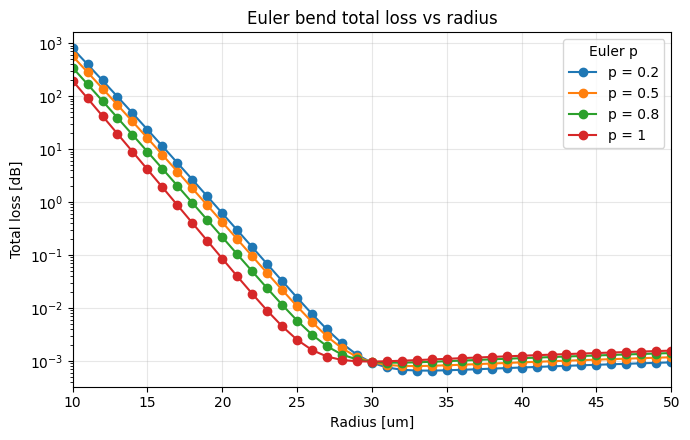

In [47]:


fig, ax = plt.subplots(figsize=(7, 4.5))

p_selected = [0.2, 0.5, 0.8, 1.0]

for p_value, group in df.groupby("p"):
    if p_value in p_selected:
        group = group.sort_values("radius")

        ax.plot(
            group["radius"],
            group["total_loss"],
            marker="o",
            label=f"p = {p_value:g}",
        )

ax.set_yscale('log')
ax.set_xlabel(f"Radius [um]")
ax.set_xlim([10, 50])
ax.set_ylabel(f"Total loss [dB]")
ax.set_title("Euler bend total loss vs radius")
ax.grid(True, alpha=0.3)
ax.legend(title="Euler p")
plt.tight_layout()